In [1]:
import pandas as pd

In [2]:
csv_path = 'Airbnb_Open_Data.csv'
df = pd.read_csv(csv_path)

C:\Users\nabil\AppData\Local\Temp\ipykernel_21228\2088482131.py:2: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


In [67]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [3]:
df.shape

(102599, 26)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [6]:
# Variables quantitatives (types numériques)
quant_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
nb_quant = len(quant_vars)

# Variables qualitatives (types objets ou booléens)
qual_vars = df.select_dtypes(include=['object', 'bool']).columns.tolist()
nb_qual = len(qual_vars)

print(f"Variables quantitatives : {nb_quant}")
print(f"Variables qualitatives : {nb_qual}")

print("\nColonnes quantitatives :")
print(quant_vars)

print("\nColonnes qualitatives :")
print(qual_vars)


Variables quantitatives : 11
Variables qualitatives : 15

Colonnes quantitatives :
['id', 'host id', 'lat', 'long', 'Construction year', 'minimum nights', 'number of reviews', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365']

Colonnes qualitatives :
['NAME', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'price', 'service fee', 'last review', 'house_rules', 'license']


# Hypothèse : Les logements proches des attractions touristiques ont des taux d'occupation plus élevés.

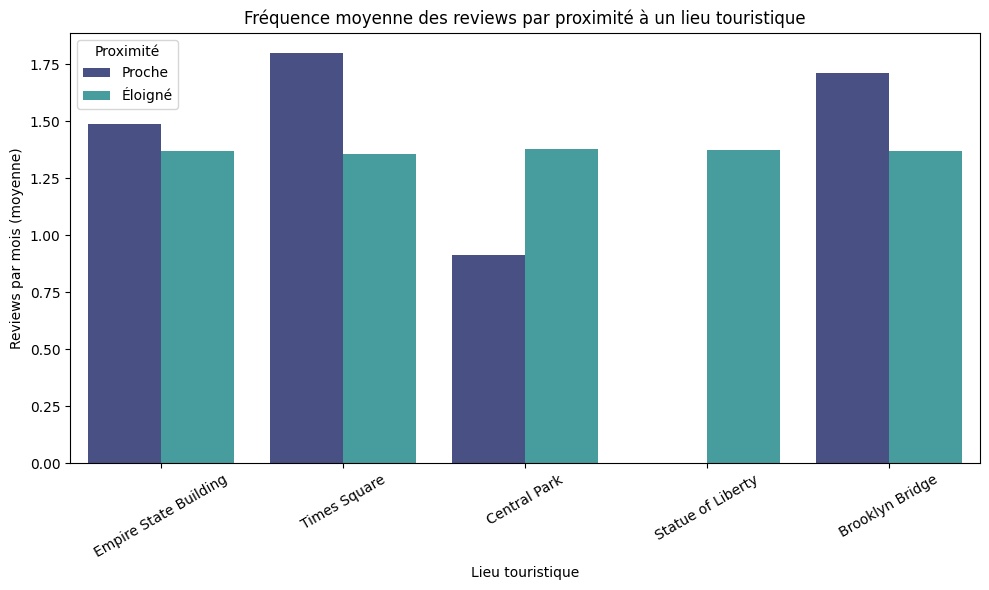

In [4]:
# importation des lib
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np



# Lieux touristiques de NYC
tourist_spots = {
    "Empire State Building": (40.748817, -73.985428),
    "Times Square": (40.7580, -73.9855),
    "Central Park": (40.785091, -73.968285),
    "Statue of Liberty": (40.6892, -74.0445),
    "Brooklyn Bridge": (40.7061, -73.9969)
}

df = df.dropna(subset=["lat", "long"])

# Calcul des distances empiriques et classification proche/éloigné
for name, coords in tourist_spots.items():
    col_dist = f"distance_{name.split()[0].lower()}"
    col_proche = f"proche_{name.split()[0].lower()}"
    
    df[col_dist] = df.apply(
        lambda row: geodesic((row["lat"], row["long"]), coords).meters,
        axis=1
    )
    df[col_proche] = df[col_dist] < 1000  # Moins de 1 km

# Préparation du DataFrame pour le graphique

records = []
for name in tourist_spots.keys():
    key = name.split()[0].lower()
    for prox_value in [True, False]:
        avg_review = df[df[f"proche_{key}"] == prox_value]["reviews per month"].mean()
        records.append({
            "Lieu": name,
            "Proximité": "Proche" if prox_value else "Éloigné",
            "Reviews_moy": avg_review
        })

df_plot = pd.DataFrame(records)

# Barplot comparatif
plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x="Lieu", y="Reviews_moy", hue="Proximité", palette="mako")
plt.title("Fréquence moyenne des reviews par proximité à un lieu touristique")
plt.ylabel("Reviews par mois (moyenne)")
plt.xlabel("Lieu touristique")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# Hypothèse : Les logements sans règles strictes sont plus souvent disponibles.

In [5]:
# availability 365 : C’est le nombre de jours où le logement est disponible à la réservation sur Airbnb dans l’année
df["availability 365"].describe()

count    102143.000000
mean        141.131903
std         135.437821
min         -10.000000
25%           3.000000
50%          96.000000
75%         269.000000
max        3677.000000
Name: availability 365, dtype: float64

In [11]:
df["house_rules_clean"] = df["house_rules"].fillna("").str.lower()

strict_keywords = ["no smoking", "No smoking" , "no shoes", "No shoes" ,"no visitors", "no parties", "quiet hours", "no pets","No pets",  "no loud music", "Clean", "DO", "NOT"]

df["has_strict_rule"] = df["house_rules_clean"].apply(
    lambda text: any(kw in text for kw in strict_keywords)
)

df.groupby("has_strict_rule")["availability 365"].mean()


has_strict_rule
False    137.751975
True     126.474113
Name: availability 365, dtype: float64

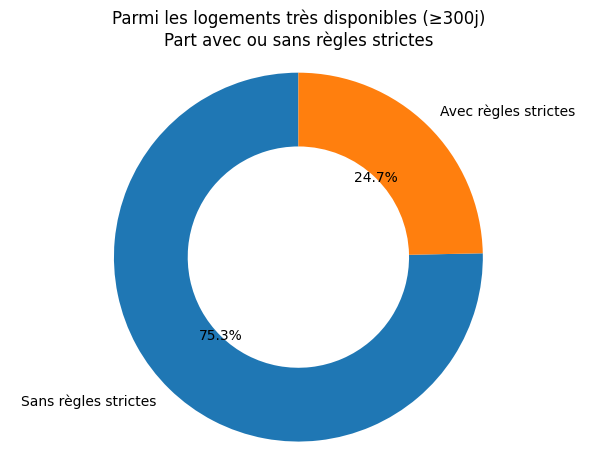

In [12]:
df["tres_dispo"] = df["availability 365"] >= 300
donut_data = df[df["tres_dispo"]]["has_strict_rule"].value_counts()

plt.pie(donut_data, labels=["Sans règles strictes", "Avec règles strictes"], autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.4))
plt.title("Parmi les logements très disponibles (≥300j)\nPart avec ou sans règles strictes")
plt.axis("equal")
plt.tight_layout()
plt.show()


# Hypothèse : Les hotels sont les plus chers

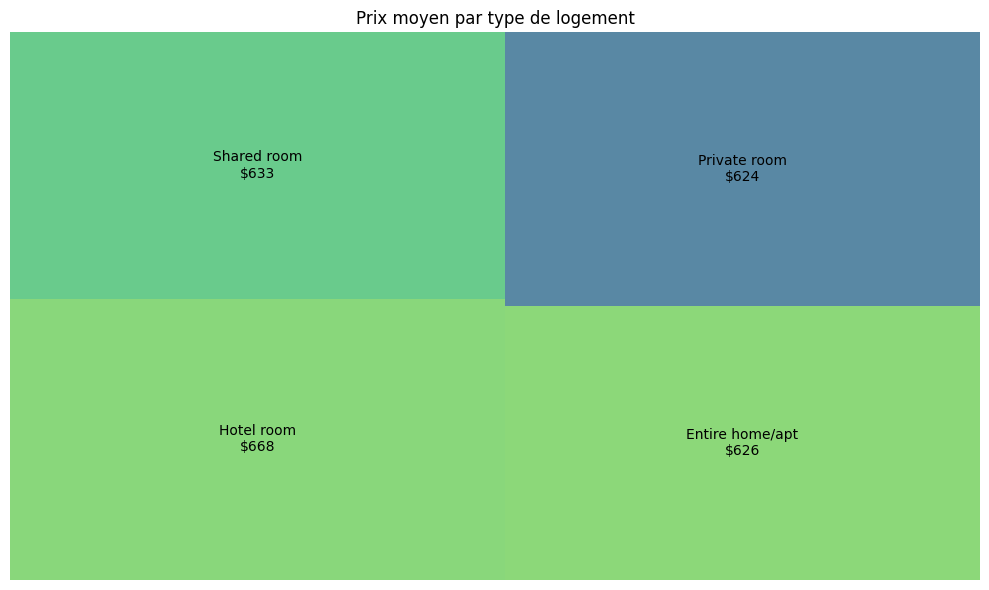

In [14]:
import matplotlib.pyplot as plt
import squarify
# Supprimer les caractères $ et convertir en float
df["price"] = df["price"].replace('[\$,]', '', regex=True).astype(float)

# Supposons que 'price' est déjà en float
price_sum = df.groupby("room type")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
squarify.plot(
    sizes=price_sum.values,
    label=[f"{k}\n${int(v):,}" for k, v in price_sum.items()],
    alpha=0.8
)
plt.title("Prix moyen par type de logement")
plt.axis("off")
plt.tight_layout()
plt.show()


# Hypothèse : Le prix dépend fortement du quartier et du type de logement

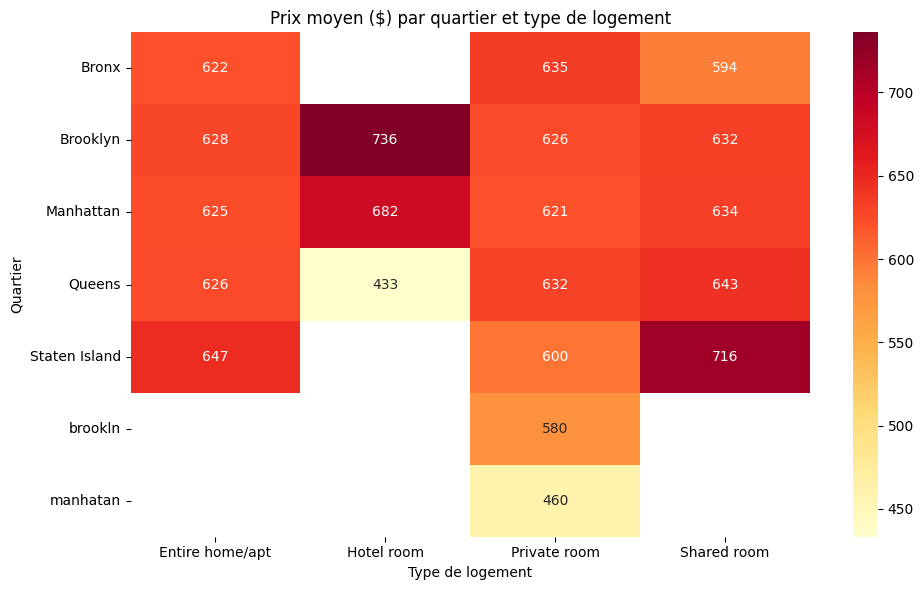

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df["price"] = df["price"].replace('[\$,]', '', regex=True).astype(float)
# Préparer une table pivot pour la heatmap
pivot_price = df.pivot_table(
    values="price",
    index="neighbourhood group",
    columns="room type",
    aggfunc="mean"
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_price, annot=True, fmt=".0f", cmap="YlOrRd", )
plt.title("Prix moyen ($) par quartier et type de logement")
plt.xlabel("Type de logement")
plt.ylabel("Quartier")
plt.tight_layout()
plt.show()


# Carte des prix et Carte des disponibilités

Les deux cartes sont sauvegardés sous format html dans votre dossier de travail

In [16]:
import folium
from folium.plugins import HeatMap
import pandas as pd


# Nettoyage
df = df[["lat", "long", "price", "availability 365"]].dropna()
df = df[(df["price"] > 0) & (df["price"] < df["price"].quantile(0.95))]
df = df[df["availability 365"].between(0, 365)]

# -----------------------------------
# 🌡️ CARTE 1 : Carte des prix
# -----------------------------------
map_price = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

HeatMap(
    data=df[["lat", "long", "price"]].values,
    radius=10,
    max_zoom=13,
    name="Prix",
).add_to(map_price)

map_price.save("heatmap_prix_airbnb.html")
print("✅ Carte des prix sauvegardée sous 'heatmap_prix_airbnb.html'")

# -----------------------------------
# 📅 CARTE 2 : Carte de la disponibilité
# -----------------------------------
map_dispo = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

HeatMap(
    data=df[["lat", "long", "availability 365"]].values,
    radius=10,
    max_zoom=13,
    name="Disponibilité",
).add_to(map_dispo)

map_dispo.save("heatmap_disponibilite_airbnb.html")
print("✅ Carte de disponibilité sauvegardée sous 'heatmap_disponibilite_airbnb.html'")



✅ Carte des prix sauvegardée sous 'heatmap_prix_airbnb.html'
✅ Carte de disponibilité sauvegardée sous 'heatmap_disponibilite_airbnb.html'


# Extra ---- test ne pas prendre en compte

Les graphs/codes ci-dessous sont simplement des test et où je n'ai pas pu tirer des conclusion --> Donc ne pas tenir compte 

In [6]:
df["cancellation_policy"].isnull().sum()

76

#### Nettoyage

In [7]:
df = df[(df["availability 365"] >= 0) & (df["availability 365"] <= 365)]
df = df.dropna(subset=["cancellation_policy"])


In [8]:
df["taux_reservation"] = 1 - (df["availability 365"] / 365)


In [9]:
df.groupby("cancellation_policy")["taux_reservation"].mean().sort_values(ascending=False)

cancellation_policy
moderate    0.633077
flexible    0.630973
strict      0.629863
Name: taux_reservation, dtype: float64

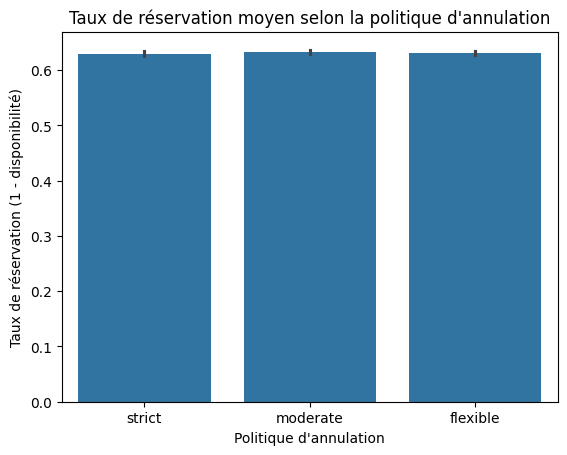

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="cancellation_policy", y="taux_reservation", data=df)
plt.title("Taux de réservation moyen selon la politique d'annulation")
plt.ylabel("Taux de réservation (1 - disponibilité)")
plt.xlabel("Politique d'annulation")
plt.show()


In [39]:
df["price"]

0           $966 
1           $142 
2           $620 
3           $368 
4           $204 
           ...   
102592      $787 
102593    $1,099 
102594      $844 
102596      $988 
102598    $1,032 
Name: price, Length: 98872, dtype: object

In [ ]:
df = df[df["price"] < df["price"].quantile(0.95)]  # enlever top 5%
xx = df.groupby("cancellation_policy")["price"].mean().sort_values(ascending=False)
xx = xx.reset_index()  # transforme cancellation_policy en colonne normale

In [80]:
xx

,cancellation_policy,price
0,flexible,569.201456
1,strict,568.156598
2,moderate,567.962895


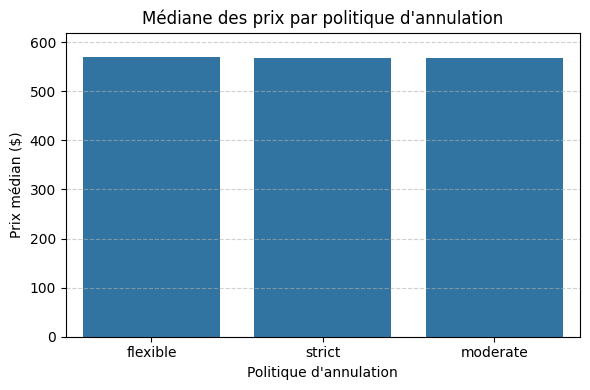

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.barplot(x="cancellation_policy", y="price", data=xx)
plt.title("Médiane des prix par politique d'annulation")
plt.ylabel("Prix médian ($)")
plt.xlabel("Politique d'annulation")
plt.ylim(0, xx["price"].max() + 50)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()




In [ ]:
df.groupby("host_identity_verified")["price"].mean()


host_identity_verified
unconfirmed    569.276823
verified       568.411622
Name: price, dtype: float64

In [70]:
df.groupby("host_identity_verified")["number of reviews"].mean()


host_identity_verified
unconfirmed    27.605294
verified       27.266894
Name: number of reviews, dtype: float64

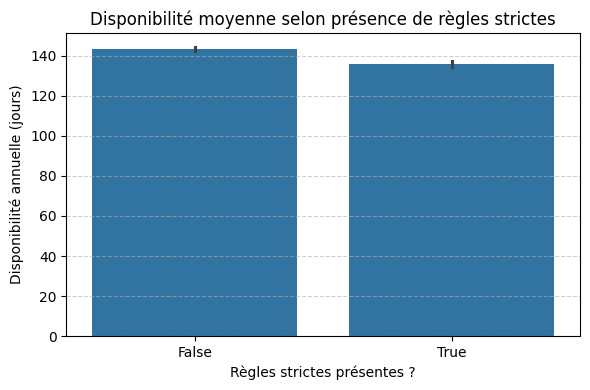

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.barplot(x="has_strict_rule", y="availability 365", data=df)
plt.title("Disponibilité moyenne selon présence de règles strictes")
plt.xlabel("Règles strictes présentes ?")
plt.ylabel("Disponibilité annuelle (jours)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


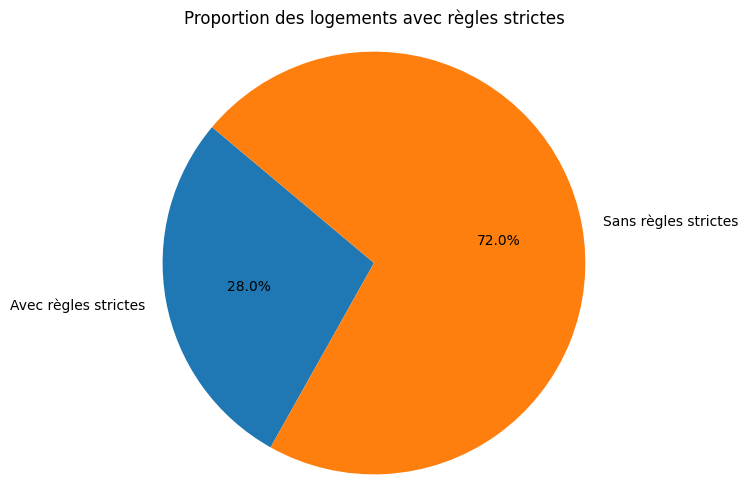

In [76]:
labels = ["Avec règles strictes", "Sans règles strictes"]
counts = df["has_strict_rule"].value_counts()
sizes = [counts[True], counts[False]]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=140)
plt.title("Proportion des logements avec règles strictes")
plt.axis("equal")
plt.show()


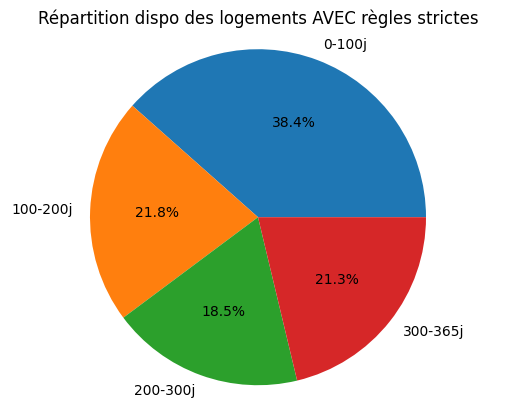

In [78]:
df["dispo_range"] = pd.cut(
    df["availability 365"], 
    bins=[0, 100, 200, 300, 366], 
    labels=["0-100j", "100-200j", "200-300j", "300-365j"]
)

strict_counts = df[df["has_strict_rule"] == True]["dispo_range"].value_counts().sort_index()
no_strict_counts = df[df["has_strict_rule"] == False]["dispo_range"].value_counts().sort_index()

# Camembert des logements AVEC règles strictes par tranche de dispo
plt.pie(strict_counts, labels=strict_counts.index, autopct='%1.1f%%')
plt.title("Répartition dispo des logements AVEC règles strictes")
plt.axis("equal")
plt.show()


In [83]:
df["name_clean"] = df["NAME"].fillna("").str.lower()

C:\Users\nabil\AppData\Local\Temp\ipykernel_18396\232322807.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["name_clean"] = df["NAME"].fillna("").str.lower()


In [84]:
keywords = ["cozy", "luxury", "romantic"]
df["has_marketing_keyword"] = df["name_clean"].apply(
    lambda x: any(kw in x for kw in keywords)
)


C:\Users\nabil\AppData\Local\Temp\ipykernel_18396\1069139685.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["has_marketing_keyword"] = df["name_clean"].apply(


In [86]:
df.groupby("has_marketing_keyword")["number of reviews"].mean()


has_marketing_keyword
False    27.600076
True     26.819981
Name: number of reviews, dtype: float64

In [87]:
keywords = ["cozy", "luxury", "romantic"]
df["name_clean"] = df["NAME"].fillna("").str.lower()
df["has_marketing_keyword"] = df["name_clean"].apply(
    lambda x: any(kw in x for kw in keywords)
)
top_rated = df[df["number of reviews"] >= 95]


C:\Users\nabil\AppData\Local\Temp\ipykernel_18396\1494450407.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["name_clean"] = df["NAME"].fillna("").str.lower()
C:\Users\nabil\AppData\Local\Temp\ipykernel_18396\1494450407.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["has_marketing_keyword"] = df["name_clean"].apply(


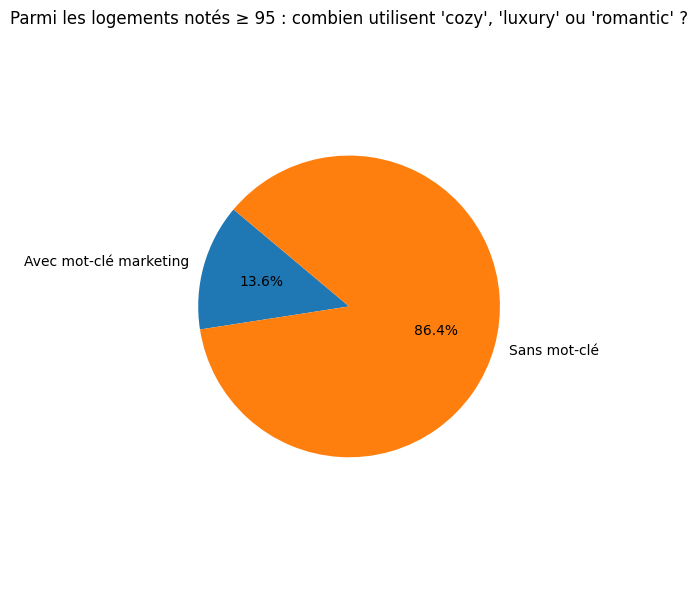

In [88]:
counts = top_rated["has_marketing_keyword"].value_counts()
labels = ["Avec mot-clé marketing", "Sans mot-clé"]
sizes = [counts.get(True, 0), counts.get(False, 0)]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title("Parmi les logements notés ≥ 95 : combien utilisent 'cozy', 'luxury' ou 'romantic' ?")
plt.axis("equal")
plt.tight_layout()
plt.show()


In [124]:
df = df[df["availability 365"].between(0, 365)]


In [126]:
df[["Construction year", "availability 365"]].corr()


,Construction year,availability 365
Construction year,1.000000,-0.007958
availability 365,-0.007958,1.000000


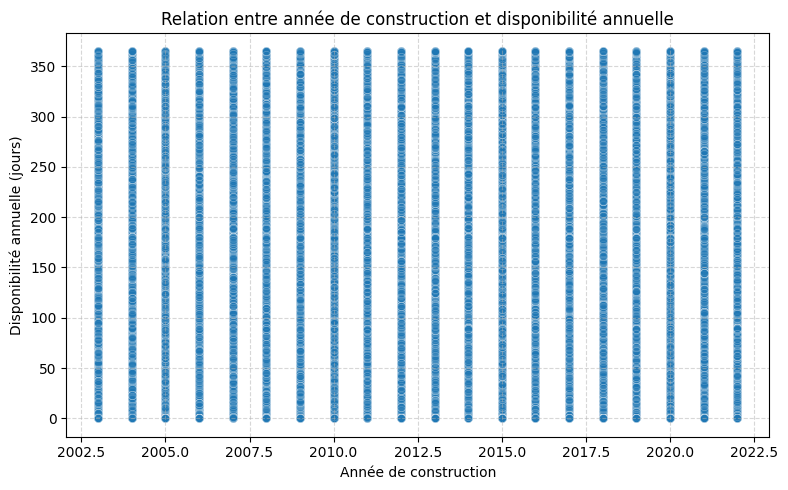

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.scatterplot(x="Construction year", y="availability 365", data=df, alpha=0.3)

plt.title("Relation entre année de construction et disponibilité annuelle")
plt.xlabel("Année de construction")
plt.ylabel("Disponibilité annuelle (jours)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [129]:
df["construction_range"] = pd.cut(df["Construction year"], bins=[2000, 2005, 2010, 2015, 2020, 2025], 
                                   labels=["2001-05", "2006-10", "2011-15", "2016-20", "2021-25"])


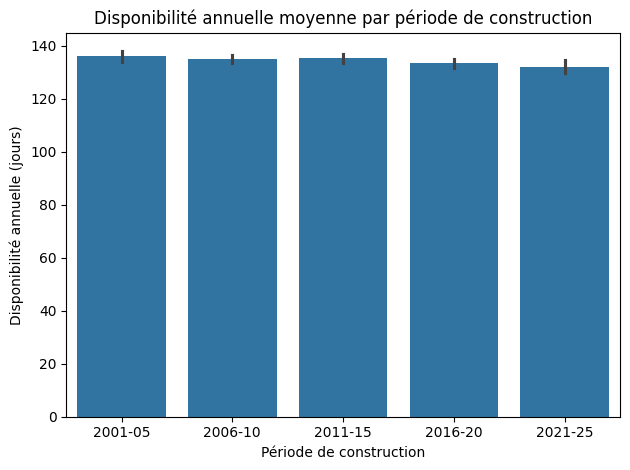

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="construction_range", y="availability 365", data=df)
plt.title("Disponibilité annuelle moyenne par période de construction")
plt.xlabel("Période de construction")
plt.ylabel("Disponibilité annuelle (jours)")
plt.tight_layout()
plt.show()
